In [15]:
! pip install -U matplotlib_venn --no-dependencies

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib_venn: filename=matplotlib_venn-0.11.9-py3-none-any.whl size=32999 sha256=a4204b4944c8f998f55b6dfc39fad9dc532952ec1be11d70844dbd0dbe9c08d3
  Stored in directory: /home/r20user3/.cache/pip/wheels/f6/80/48/193eff32ed8e176623b15874055438ecec522ba68ed05abee6
Successfully built matplotlib_venn


In [1]:
# define moran's R calculation function

from scipy.sparse import csc_matrix, csr_matrix, issparse, hstack
from scipy import stats
import numpy as np

# pure statistics for bivariate Moran's R
def Moran_R_std(spatial_W, by_trace=False):
    """Calculate standard deviation of Moran's R under the null distribution.
    """
    N = spatial_W.shape[0]

    if by_trace:
        W = spatial_W.copy()
        H = np.identity(N) - np.ones((N, N)) / N
        HWH = H.dot(W.dot(H))
        var = np.trace(HWH.dot(HWH)) * N**2 / (np.sum(W) * (N-1))**2
    else:
        if issparse(spatial_W):
            nm = N ** 2 * spatial_W.multiply(spatial_W.T).sum() \
                - 2 * N * (spatial_W.sum(0) @ spatial_W.sum(1)).sum() \
                + spatial_W.sum() ** 2
        else:
            nm = N ** 2 * (spatial_W * spatial_W.T).sum() \
                - 2 * N * (spatial_W.sum(1) * spatial_W.sum(0)).sum() \
                + spatial_W.sum() ** 2
        dm = N ** 2 * (N - 1) ** 2
        var = nm / dm

    return np.sqrt(var)


def Moran_R(X, Y, spatial_W, standardise=True, nproc=1):
    """Computing Moran's R for pairs of variables
    
    :param X: Variable 1, (n_sample, n_variables) or (n_sample, )
    :param Y: Variable 2, (n_sample, n_variables) or (n_sample, )
    :param spatial_W: spatial weight matrix, sparse or dense, (n_sample, n_sample)
    :param nproc: default to 1. Numpy may use more without much speedup.
    
    :return: (Moran's R, z score and p values)
    """
    if len(X.shape) < 2:
        X = X.reshape(-1, 1)
    if len(Y.shape) < 2:
        Y = Y.reshape(-1, 1)

    if standardise:
        X = (X - np.mean(X, axis=0, keepdims=True)) / np.std(X, axis=0, keepdims=True)
        Y = (Y - np.mean(Y, axis=0, keepdims=True)) / np.std(Y, axis=0, keepdims=True)

    # Consider to dense array for speedup (numpy's codes is optimised)
    if X.shape[0] <= 5000 and issparse(spatial_W):
        # Note, numpy may use unnessary too many threads
        # You may use threadpool.threadpool_limits() outside
        from threadpoolctl import threadpool_limits

        with threadpool_limits(limits=nproc, user_api='blas'):
            R_val = (spatial_W.A @ X * Y).sum(axis=0) / np.sum(spatial_W)
    else:
        # we assume it's sparse spatial_W when sample size > 5000
        R_val = (spatial_W @ X * Y).sum(axis=0) / np.sum(spatial_W)

    _R_std = Moran_R_std(spatial_W)
    R_z_score = R_val / _R_std
    R_p_val = stats.norm.sf(R_z_score)

    return R_val, R_z_score, R_p_val

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/spatialdata/__init__.py:9: UserWarning: Geopandas was set to use PyGEOS, changing to shapely 2.0 with:

	geopandas.options.use_pygeos = True

If you intended to use PyGEOS, set the option to False.
  _check_geopandas_using_shapely()
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scipy/sparse/_compressed.py:290: SparseEfficiencyWarning: Comparing a sparse matrix with a scalar greater than zero using < is inefficient, try using >= instead.
  warn(bad_scalar_msg, SparseEfficiencyWarning)
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity 

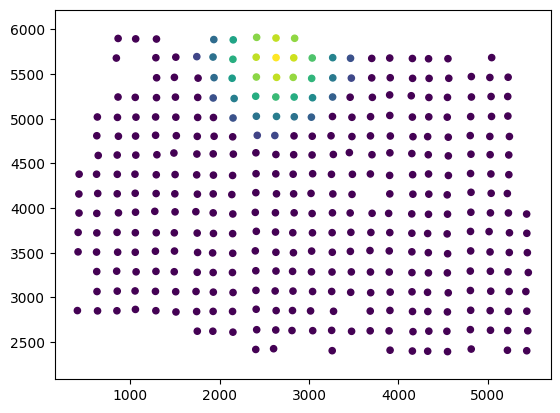

In [2]:
import pandas as pd
import numpy as np
import anndata as ad
from scipy.sparse import csr_matrix
import joblib
import squidpy as sq

cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/A1/cell_ratio.csv").columns)[1:]]

case = "A"
save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/her2st/her2st_epoch100_lr1e-4_2hop_ensemble_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
pred_and_label = joblib.load(save_path)

slide = list(pred_and_label.keys())[0]

spot_coord = pred_and_label[slide]['coords']
spot_coord = spot_coord
X = csr_matrix(pred_and_label[slide]['cell_abundance_labels'])
adata = ad.AnnData(X, obsm={"spatial": spot_coord})

adata.var_names = cell_names

# create sptial weight matrix for cell abundance ground truth

import spatialdm as sdm
import matplotlib.pyplot as plt

sdm.weight_matrix(adata, l=500, cutoff=0.2, single_cell=False, n_neighbors=160) # weight_matrix by rbf kernel
plt.scatter(list(adata.obsm['spatial'][:,0]), list(adata.obsm['spatial'][:,1]),
            c=adata.obsp['weight'].A[50], s=20.0)
plt.axis('equal')
plt.show()

In [3]:
# get all cell type pair combinations

import os

combinations = []

for i in range(len(cell_names)):
    for j in range(i+1, len(cell_names)):
        combinations.append((cell_names[i], cell_names[j]))

# calculate moran's R for all cell type pairs

from tqdm import tqdm

df = pd.DataFrame(columns=['A', 'B', 'R_val', 'R_z_score', 'R_p_val'])
for pair in tqdm(combinations):
    X = adata[:, pair[0]].X.A
    Y = adata[:, pair[1]].X.A
    R_val, R_z_score, R_p_val = Moran_R(X, Y, adata.obsp['weight'])
    df.loc[len(df)] = [pair[0], pair[1], R_val[0], R_z_score[0], R_p_val[0]]

100%|██████████| 741/741 [00:03<00:00, 212.15it/s]


In [4]:
# sort according to the moran's R score

df_label = df.sort_values('R_val', ascending=False)
df_label

,A,B,R_val,R_z_score,R_p_val
250,"activated CD8-positive, alpha-beta T cell",conventional dendritic cell,0.270944,31.727244,3.271333e-221
269,"activated CD8-positive, alpha-beta T cell",non-classical monocyte,0.261204,30.586798,9.169285e-206
434,conventional dendritic cell,non-classical monocyte,0.246054,28.812675,7.440876e-183
272,"activated CD8-positive, alpha-beta T cell",regulatory T cell,0.236463,27.689661,4.650264e-169
437,conventional dendritic cell,regulatory T cell,0.230348,26.973584,1.508817e-160
...,...,...,...,...,...
589,luminal epithelial cell of mammary gland,macrophage,-0.104406,-12.225866,1.000000e+00
128,IgA plasma cell,luminal epithelial cell of mammary gland,-0.104413,-12.226683,1.000000e+00
251,"activated CD8-positive, alpha-beta T cell","effector memory CD4-positive, alpha-beta T cell",-0.106542,-12.475961,1.000000e+00
598,luminal epithelial cell of mammary gland,non-classical monocyte,-0.120727,-14.137073,1.000000e+00


In [5]:
df_figure = df_label[['A', 'B', 'R_val']]

# Pivot the DataFrame to have variable names as index and columns, and correlation values as data
correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")

# Fill the diagonal with 1s, as the correlation of a variable with itself is 1
for var in correlation_df.index:
    correlation_df.at[var, var] = 1

# Fill the missing values with the transpose of the DataFrame to make it symmetric
correlation_df = correlation_df.combine_first(correlation_df.T)

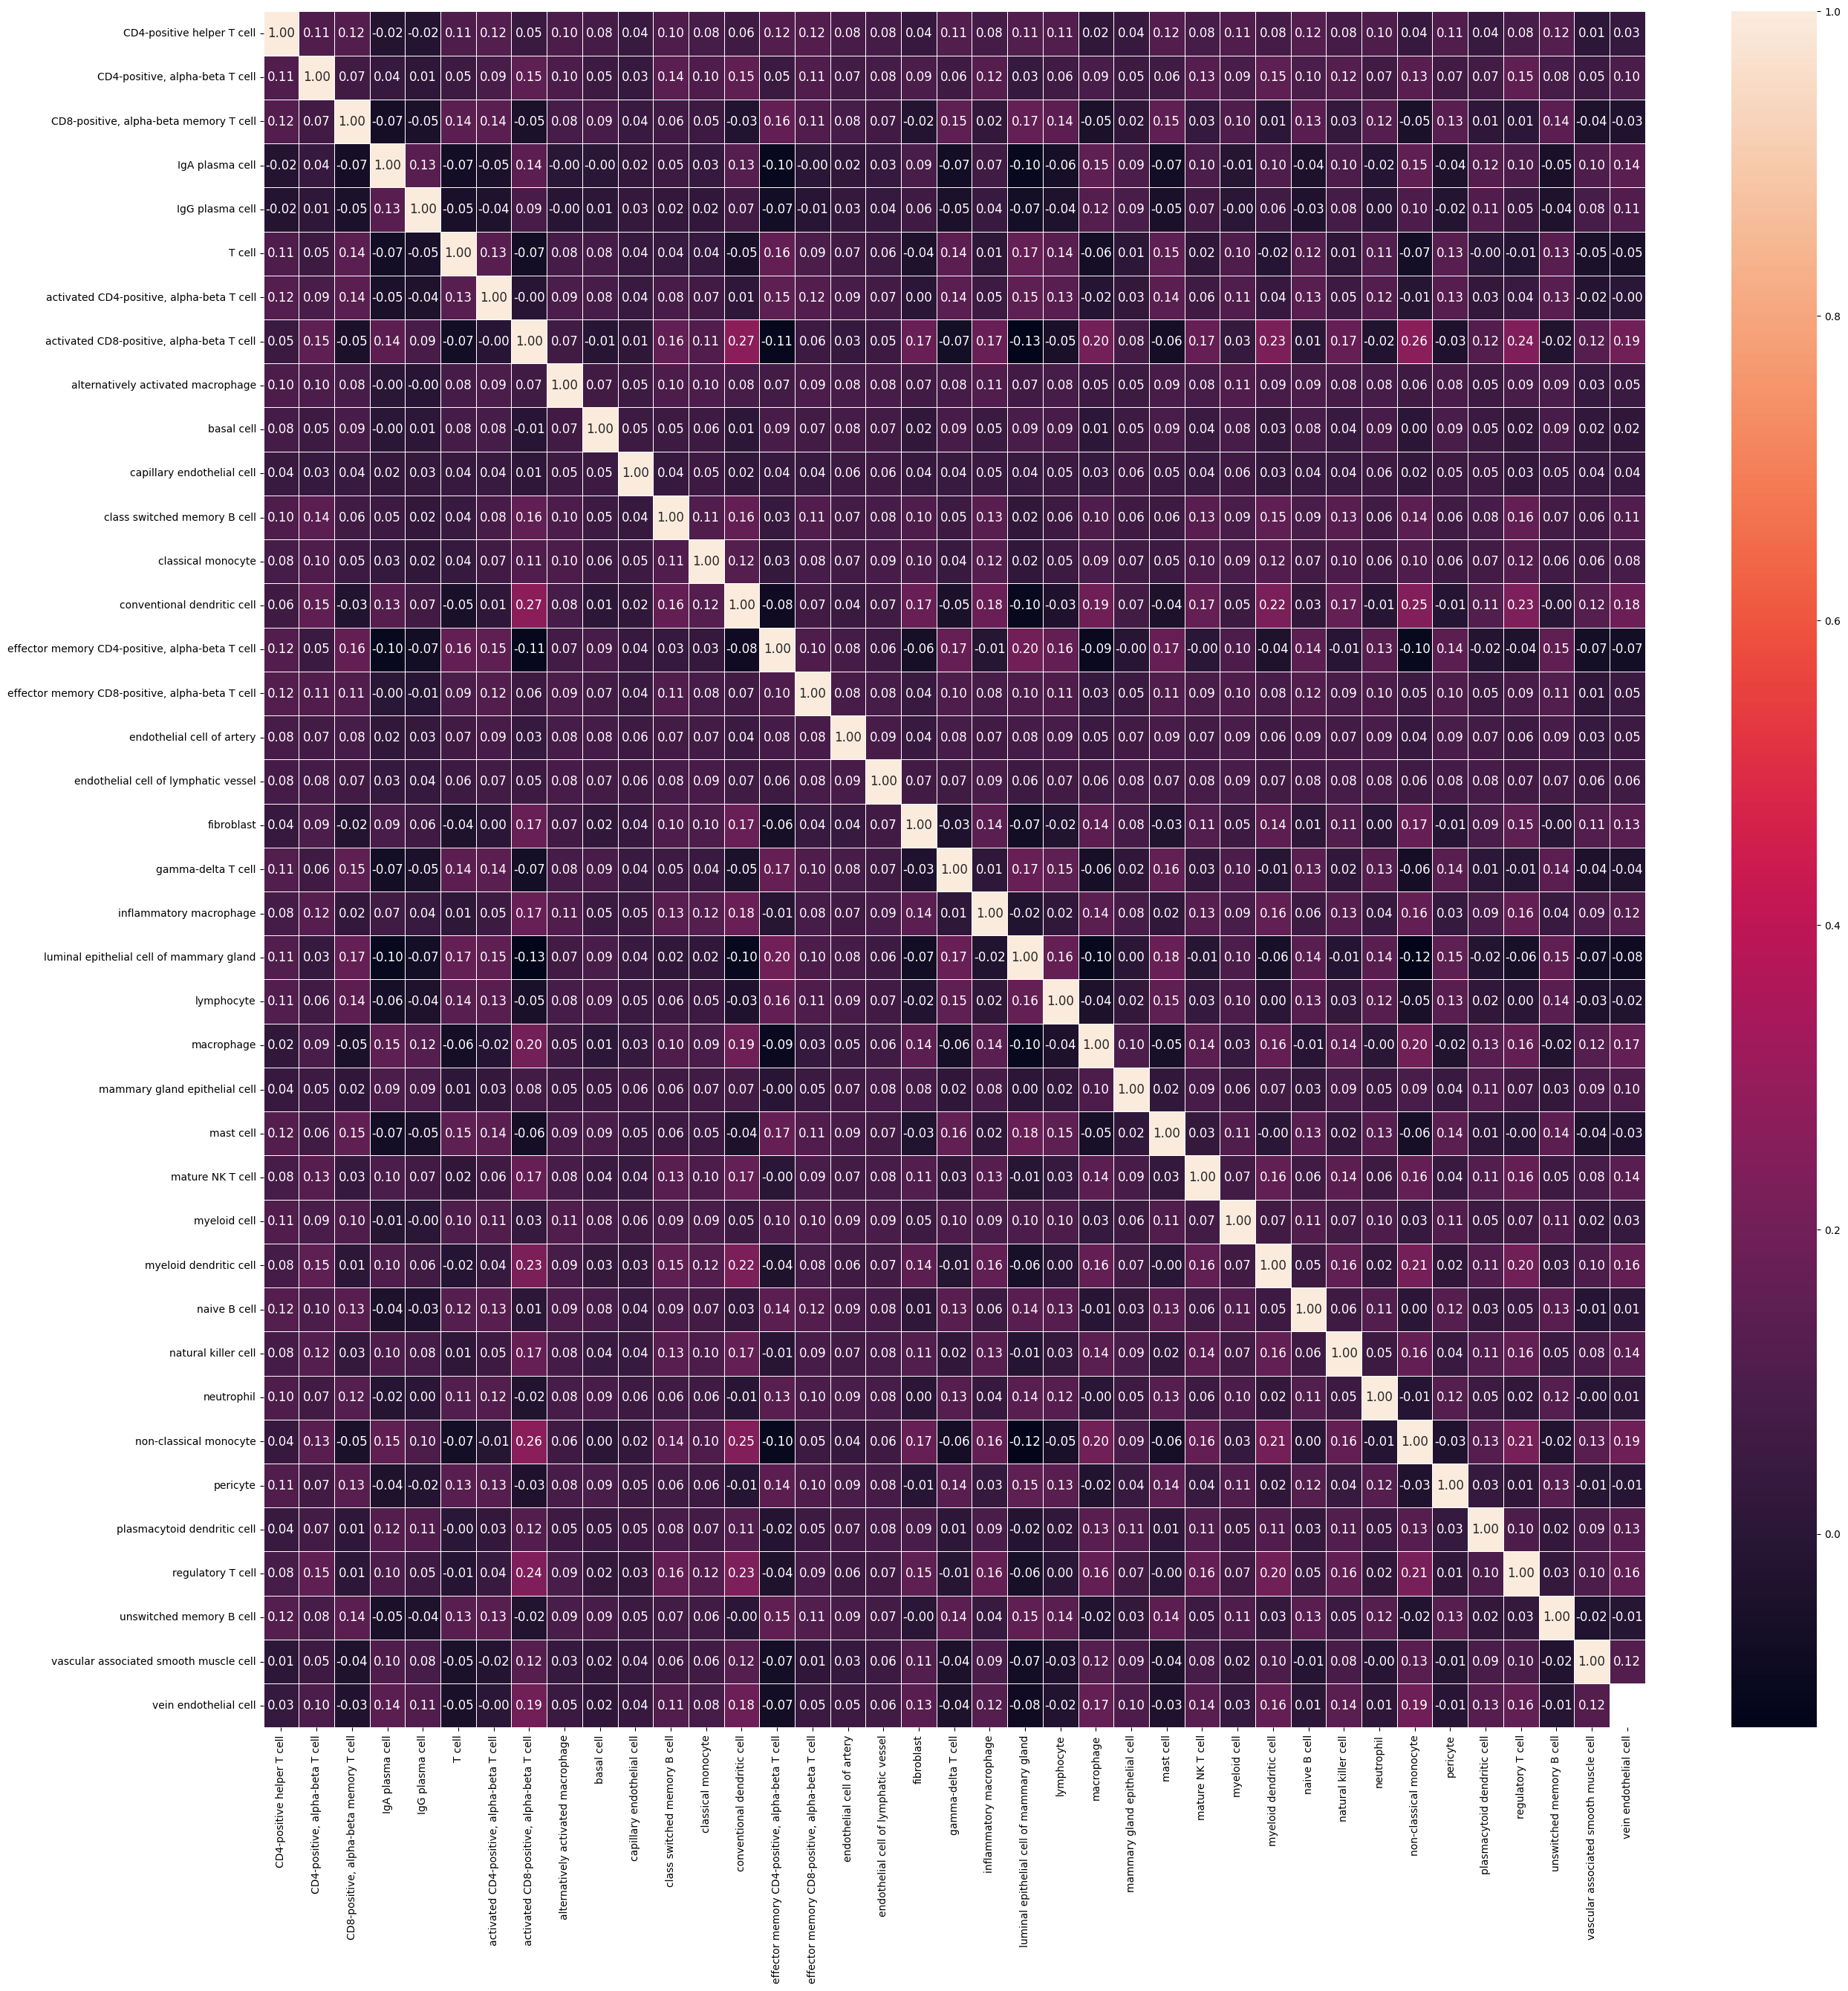

In [6]:
import seaborn as sns

# Set the figure size (width, height) in inches
plt.figure(figsize=(30, 30))

# Create a heatmap
sns.heatmap(correlation_df, annot=True, fmt='.2f', linewidths=.5, annot_kws={"size": 12})

# Show the plot
plt.show()

/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scipy/sparse/_compressed.py:290: SparseEfficiencyWarning: Comparing a sparse matrix with a scalar greater than zero using < is inefficient, try using >= instead.
  warn(bad_scalar_msg, SparseEfficiencyWarning)
/home/r20user3/anaconda3/envs/gene/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


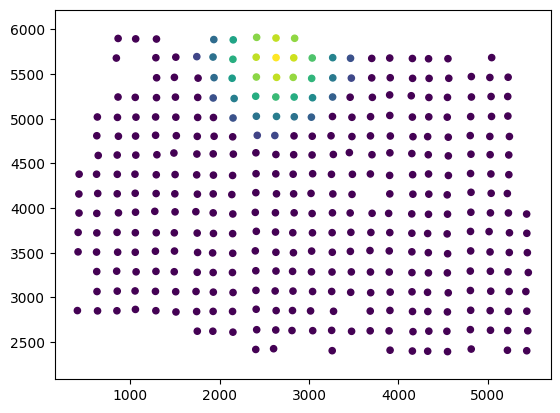

In [7]:
spot_coord = pred_and_label[slide]['coords']
spot_coord = spot_coord
X = csr_matrix(pred_and_label[slide]['cell_abundance_predictions'])
adata = ad.AnnData(X, obsm={"spatial": spot_coord})

adata.var_names = cell_names

# create sptial weight matrix for cell abundance ground truth

import spatialdm as sdm
import matplotlib.pyplot as plt

sdm.weight_matrix(adata, l=500, cutoff=0.2, single_cell=False) # weight_matrix by rbf kernel
plt.scatter(list(adata.obsm['spatial'][:,0]), list(adata.obsm['spatial'][:,1]),
            c=adata.obsp['weight'].A[50], s=20.0)
plt.axis('equal')
plt.show()

In [8]:
# get all cell type pair combinations

import os

combinations = []

for i in range(len(cell_names)):
    for j in range(i+1, len(cell_names)):
        combinations.append((cell_names[i], cell_names[j]))

# calculate moran's R for all cell type pairs

from tqdm import tqdm

df = pd.DataFrame(columns=['A', 'B', 'R_val', 'R_z_score', 'R_p_val'])
for pair in tqdm(combinations):
    X = adata[:, pair[0]].X.A
    Y = adata[:, pair[1]].X.A
    R_val, R_z_score, R_p_val = Moran_R(X, Y, adata.obsp['weight'])
    df.loc[len(df)] = [pair[0], pair[1], R_val[0], R_z_score[0], R_p_val[0]]

100%|██████████| 741/741 [00:03<00:00, 193.05it/s]


In [9]:
# sort according to the moran's R score

df_pred = df.sort_values('R_val', ascending=False)
df_pred

,A,B,R_val,R_z_score,R_p_val
195,T cell,luminal epithelial cell of mammary gland,0.254683,29.823112,9.799445e-196
447,"effector memory CD4-positive, alpha-beta T cell",luminal epithelial cell of mammary gland,0.250762,29.363964,7.925738e-190
188,T cell,"effector memory CD4-positive, alpha-beta T cell",0.242164,28.357134,3.417699e-177
313,basal cell,endothelial cell of lymphatic vessel,0.237116,27.766061,5.575363e-170
492,endothelial cell of artery,luminal epithelial cell of mammary gland,0.227836,26.679403,4.081049e-157
...,...,...,...,...,...
247,"activated CD8-positive, alpha-beta T cell",capillary endothelial cell,-0.139325,-16.314834,1.000000e+00
181,T cell,"activated CD8-positive, alpha-beta T cell",-0.139836,-16.374679,1.000000e+00
258,"activated CD8-positive, alpha-beta T cell",luminal epithelial cell of mammary gland,-0.140445,-16.446036,1.000000e+00
254,"activated CD8-positive, alpha-beta T cell",endothelial cell of lymphatic vessel,-0.145035,-16.983410,1.000000e+00


In [10]:
df_figure = df_pred[['A', 'B', 'R_val']]

# Pivot the DataFrame to have variable names as index and columns, and correlation values as data
correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")

# Fill the diagonal with 1s, as the correlation of a variable with itself is 1
for var in correlation_df.index:
    correlation_df.at[var, var] = 1

# Fill the missing values with the transpose of the DataFrame to make it symmetric
correlation_df = correlation_df.combine_first(correlation_df.T)

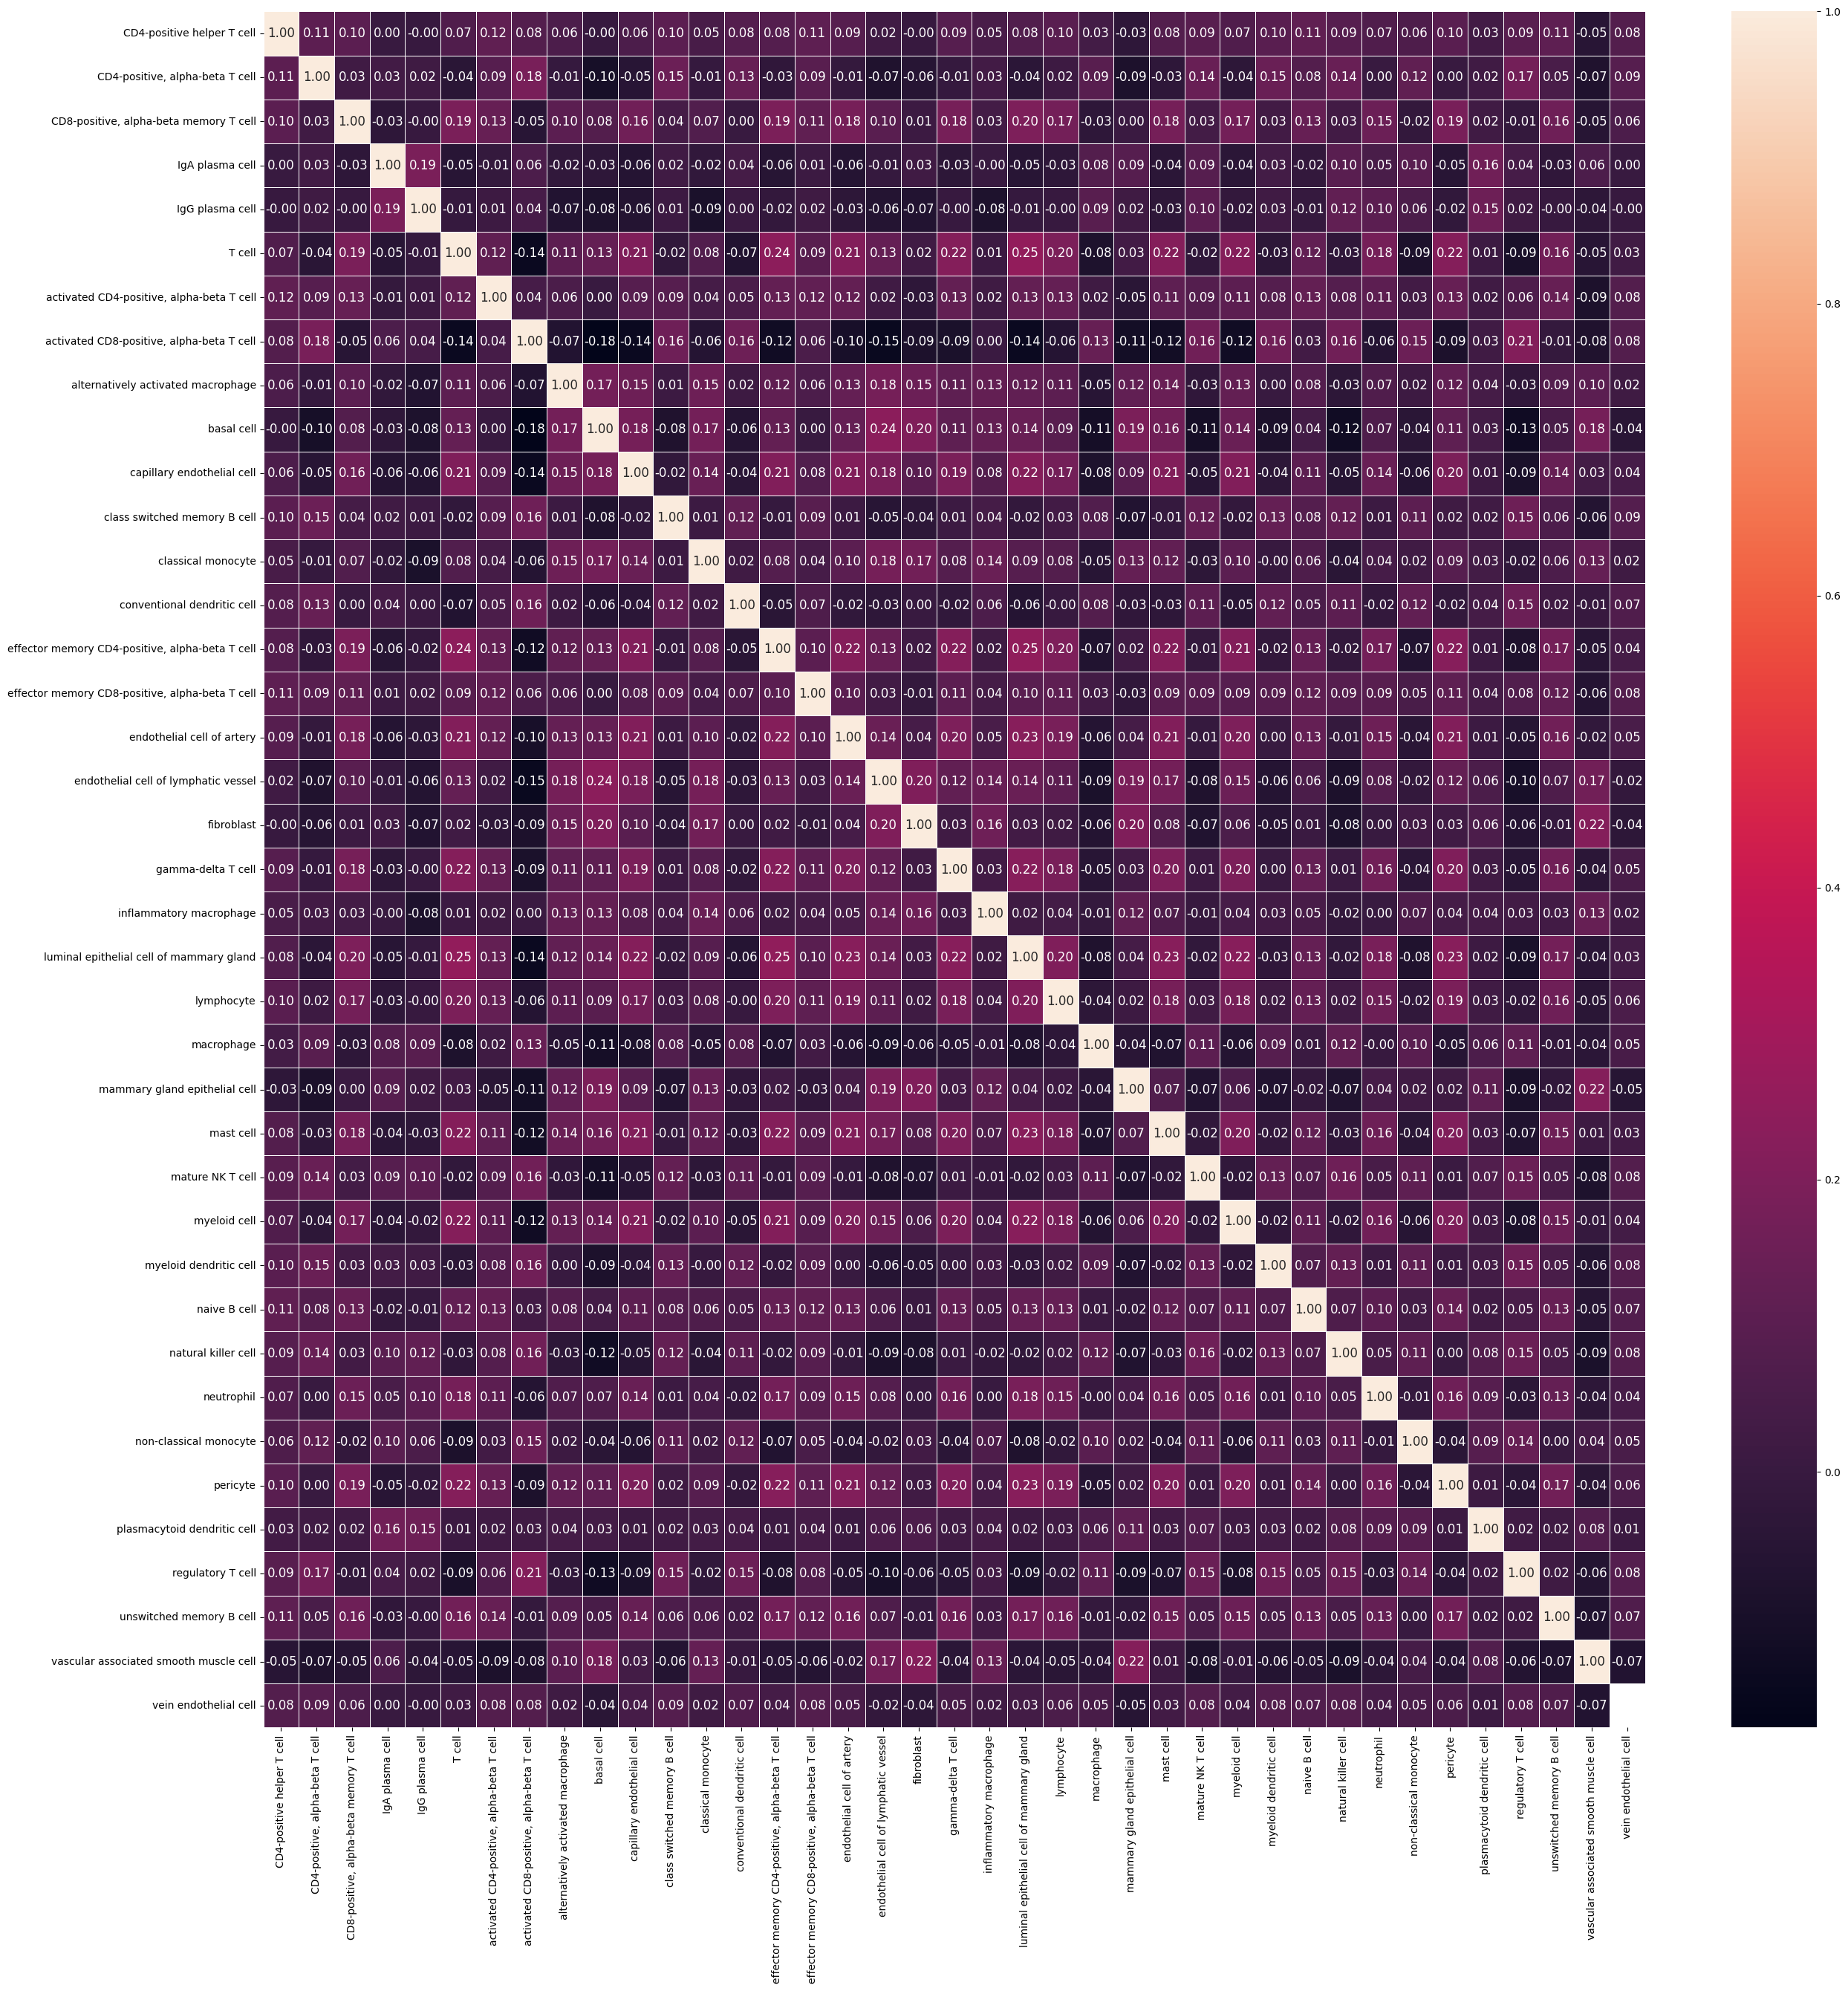

In [11]:
import seaborn as sns

# Set the figure size (width, height) in inches
plt.figure(figsize=(30, 30))

# Create a heatmap
sns.heatmap(correlation_df, annot=True, fmt='.2f', linewidths=.5, annot_kws={"size": 12})

# Show the plot
plt.show()

In [12]:
df_label

,A,B,R_val,R_z_score,R_p_val
250,"activated CD8-positive, alpha-beta T cell",conventional dendritic cell,0.270944,31.727244,3.271333e-221
269,"activated CD8-positive, alpha-beta T cell",non-classical monocyte,0.261204,30.586798,9.169285e-206
434,conventional dendritic cell,non-classical monocyte,0.246054,28.812675,7.440876e-183
272,"activated CD8-positive, alpha-beta T cell",regulatory T cell,0.236463,27.689661,4.650264e-169
437,conventional dendritic cell,regulatory T cell,0.230348,26.973584,1.508817e-160
...,...,...,...,...,...
589,luminal epithelial cell of mammary gland,macrophage,-0.104406,-12.225866,1.000000e+00
128,IgA plasma cell,luminal epithelial cell of mammary gland,-0.104413,-12.226683,1.000000e+00
251,"activated CD8-positive, alpha-beta T cell","effector memory CD4-positive, alpha-beta T cell",-0.106542,-12.475961,1.000000e+00
598,luminal epithelial cell of mammary gland,non-classical monocyte,-0.120727,-14.137073,1.000000e+00


In [13]:
df_pred

,A,B,R_val,R_z_score,R_p_val
195,T cell,luminal epithelial cell of mammary gland,0.254683,29.823112,9.799445e-196
447,"effector memory CD4-positive, alpha-beta T cell",luminal epithelial cell of mammary gland,0.250762,29.363964,7.925738e-190
188,T cell,"effector memory CD4-positive, alpha-beta T cell",0.242164,28.357134,3.417699e-177
313,basal cell,endothelial cell of lymphatic vessel,0.237116,27.766061,5.575363e-170
492,endothelial cell of artery,luminal epithelial cell of mammary gland,0.227836,26.679403,4.081049e-157
...,...,...,...,...,...
247,"activated CD8-positive, alpha-beta T cell",capillary endothelial cell,-0.139325,-16.314834,1.000000e+00
181,T cell,"activated CD8-positive, alpha-beta T cell",-0.139836,-16.374679,1.000000e+00
258,"activated CD8-positive, alpha-beta T cell",luminal epithelial cell of mammary gland,-0.140445,-16.446036,1.000000e+00
254,"activated CD8-positive, alpha-beta T cell",endothelial cell of lymphatic vessel,-0.145035,-16.983410,1.000000e+00


In [22]:
df_pred['pair'] = df_pred.apply(lambda row: str(row['A']) + '_' + str(row['B']), axis=1)
df_pred

,A,B,R_val,R_z_score,R_p_val,pair
195,T cell,luminal epithelial cell of mammary gland,0.254683,29.823112,9.799445e-196,T cell_luminal epithelial cell of mammary gland
447,"effector memory CD4-positive, alpha-beta T cell",luminal epithelial cell of mammary gland,0.250762,29.363964,7.925738e-190,"effector memory CD4-positive, alpha-beta T cel..."
188,T cell,"effector memory CD4-positive, alpha-beta T cell",0.242164,28.357134,3.417699e-177,"T cell_effector memory CD4-positive, alpha-bet..."
313,basal cell,endothelial cell of lymphatic vessel,0.237116,27.766061,5.575363e-170,basal cell_endothelial cell of lymphatic vessel
492,endothelial cell of artery,luminal epithelial cell of mammary gland,0.227836,26.679403,4.081049e-157,endothelial cell of artery_luminal epithelial ...
...,...,...,...,...,...,...
247,"activated CD8-positive, alpha-beta T cell",capillary endothelial cell,-0.139325,-16.314834,1.000000e+00,"activated CD8-positive, alpha-beta T cell_capi..."
181,T cell,"activated CD8-positive, alpha-beta T cell",-0.139836,-16.374679,1.000000e+00,"T cell_activated CD8-positive, alpha-beta T cell"
258,"activated CD8-positive, alpha-beta T cell",luminal epithelial cell of mammary gland,-0.140445,-16.446036,1.000000e+00,"activated CD8-positive, alpha-beta T cell_lumi..."
254,"activated CD8-positive, alpha-beta T cell",endothelial cell of lymphatic vessel,-0.145035,-16.983410,1.000000e+00,"activated CD8-positive, alpha-beta T cell_endo..."


In [23]:
df_label['pair'] = df_label.apply(lambda row: str(row['A']) + '_' + str(row['B']), axis=1)
df_label

,A,B,R_val,R_z_score,R_p_val,pair
250,"activated CD8-positive, alpha-beta T cell",conventional dendritic cell,0.270944,31.727244,3.271333e-221,"activated CD8-positive, alpha-beta T cell_conv..."
269,"activated CD8-positive, alpha-beta T cell",non-classical monocyte,0.261204,30.586798,9.169285e-206,"activated CD8-positive, alpha-beta T cell_non-..."
434,conventional dendritic cell,non-classical monocyte,0.246054,28.812675,7.440876e-183,conventional dendritic cell_non-classical mono...
272,"activated CD8-positive, alpha-beta T cell",regulatory T cell,0.236463,27.689661,4.650264e-169,"activated CD8-positive, alpha-beta T cell_regu..."
437,conventional dendritic cell,regulatory T cell,0.230348,26.973584,1.508817e-160,conventional dendritic cell_regulatory T cell
...,...,...,...,...,...,...
589,luminal epithelial cell of mammary gland,macrophage,-0.104406,-12.225866,1.000000e+00,luminal epithelial cell of mammary gland_macro...
128,IgA plasma cell,luminal epithelial cell of mammary gland,-0.104413,-12.226683,1.000000e+00,IgA plasma cell_luminal epithelial cell of mam...
251,"activated CD8-positive, alpha-beta T cell","effector memory CD4-positive, alpha-beta T cell",-0.106542,-12.475961,1.000000e+00,"activated CD8-positive, alpha-beta T cell_effe..."
598,luminal epithelial cell of mammary gland,non-classical monocyte,-0.120727,-14.137073,1.000000e+00,luminal epithelial cell of mammary gland_non-c...


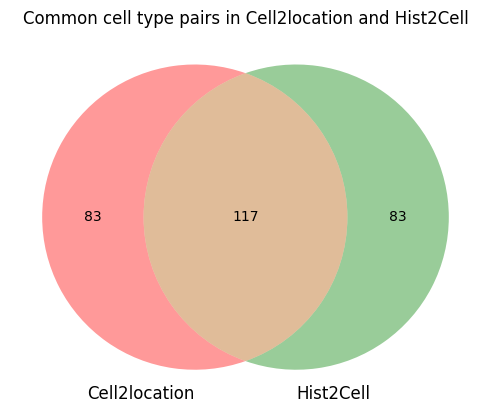

In [26]:
import pandas as pd
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Assuming you have dataframe1 and dataframe2
set1 = set(df_label.head(200)['pair'].values)
set2 = set(df_pred.head(200)['pair'].values)

venn = venn2([set1, set2], set_labels=('Cell2location', 'Hist2Cell'))
plt.title("Common cell type pairs in Cell2location and Hist2Cell")
plt.show()

In [29]:
merged_dataframe = df_label.head(200).merge(df_pred.head(200), on=['A', 'B'], suffixes=('_Cell2location', '_Hist2Cell'))
merged_dataframe

,A,B,R_val_Cell2location,R_z_score_Cell2location,R_p_val_Cell2location,pair_Cell2location,R_val_Hist2Cell,R_z_score_Hist2Cell,R_p_val_Hist2Cell,pair_Hist2Cell
0,"activated CD8-positive, alpha-beta T cell",conventional dendritic cell,0.270944,31.727244,3.271333e-221,"activated CD8-positive, alpha-beta T cell_conv...",0.155018,18.152517,6.132503e-74,"activated CD8-positive, alpha-beta T cell_conv..."
1,"activated CD8-positive, alpha-beta T cell",non-classical monocyte,0.261204,30.586798,9.169285e-206,"activated CD8-positive, alpha-beta T cell_non-...",0.148163,17.349749,9.905410e-68,"activated CD8-positive, alpha-beta T cell_non-..."
2,conventional dendritic cell,non-classical monocyte,0.246054,28.812675,7.440876e-183,conventional dendritic cell_non-classical mono...,0.122413,14.334447,6.665205e-47,conventional dendritic cell_non-classical mono...
3,"activated CD8-positive, alpha-beta T cell",regulatory T cell,0.236463,27.689661,4.650264e-169,"activated CD8-positive, alpha-beta T cell_regu...",0.211977,24.822289,2.576052e-136,"activated CD8-positive, alpha-beta T cell_regu..."
4,conventional dendritic cell,regulatory T cell,0.230348,26.973584,1.508817e-160,conventional dendritic cell_regulatory T cell,0.147569,17.280218,3.314864e-67,conventional dendritic cell_regulatory T cell
...,...,...,...,...,...,...,...,...,...,...
112,myeloid cell,naive B cell,0.107672,12.608278,9.505123e-37,myeloid cell_naive B cell,0.113019,13.234399,2.776954e-40,myeloid cell_naive B cell
113,alternatively activated macrophage,myeloid cell,0.107336,12.568947,1.564306e-36,alternatively activated macrophage_myeloid cell,0.127059,14.878482,2.273506e-50,alternatively activated macrophage_myeloid cell
114,myeloid cell,pericyte,0.106404,12.459845,6.180535e-36,myeloid cell_pericyte,0.198119,23.199598,2.297989e-119,myeloid cell_pericyte
115,myeloid cell,unswitched memory B cell,0.106075,12.421335,1.000961e-35,myeloid cell_unswitched memory B cell,0.148252,17.360134,8.266916e-68,myeloid cell_unswitched memory B cell
